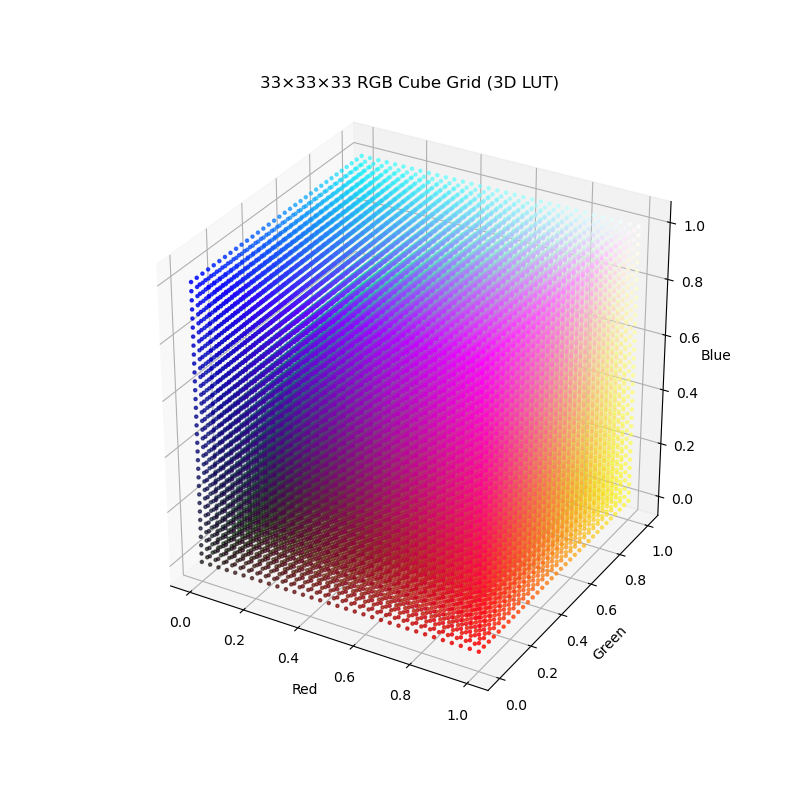

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

# LUT size
L = 33

# Create evenly spaced RGB values in [0, 1]
r = np.linspace(0, 1, L)
g = np.linspace(0, 1, L)
b = np.linspace(0, 1, L)

# Create 3D grid
R, G, B = np.meshgrid(r, g, b, indexing='ij')

# Flatten for plotting
R_flat = R.flatten()
G_flat = G.flatten()
B_flat = B.flatten()

# Stack for colors
colors = np.stack([R_flat, G_flat, B_flat], axis=1)

# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    R_flat,
    G_flat,
    B_flat,
    c=colors,
    s=5,
    marker='o'
)


# Axes labels
ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')

ax.set_title('33×33×33 RGB Cube Grid (3D LUT)')

# Equal aspect ratio
ax.set_box_aspect([1, 1, 1])

plt.show()


In [3]:
-np.log(220/255)

0.14763599880606457

In [4]:
colors

array([[0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.03125],
       [0.     , 0.     , 0.0625 ],
       ...,
       [1.     , 1.     , 0.9375 ],
       [1.     , 1.     , 0.96875],
       [1.     , 1.     , 1.     ]])

(256, 256, 3)


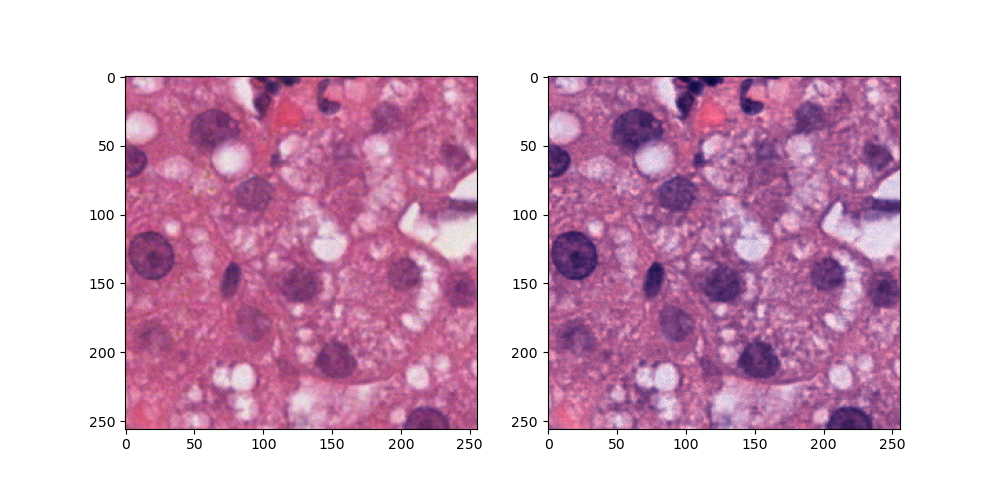

In [5]:
plt.figure(figsize=(10,5))
img_0 = (plt.imread('/home/ferbue/BKSVD-Python/data/hist0.png')*255).astype(np.uint8)[:,:,:3]
plt.subplot(121),plt.imshow(img_0)
norm_0 = (plt.imread('/home/ferbue/BKSVD-Python/data/norm_0.png')*255).astype(np.uint8)[:,:,:3]
plt.subplot(122),plt.imshow(norm_0)

print(img_0.shape)


In [6]:
img_0f = img_0/255.0
img_0f=img_0f.reshape(-1,3)
img_0f.shape

(65536, 3)

In [7]:
img_0c = img_0.reshape(-1,3)
unique_colors, color_count = np.unique(img_0c, return_counts =True, axis=0)
unique_colors.shape

(33057, 3)

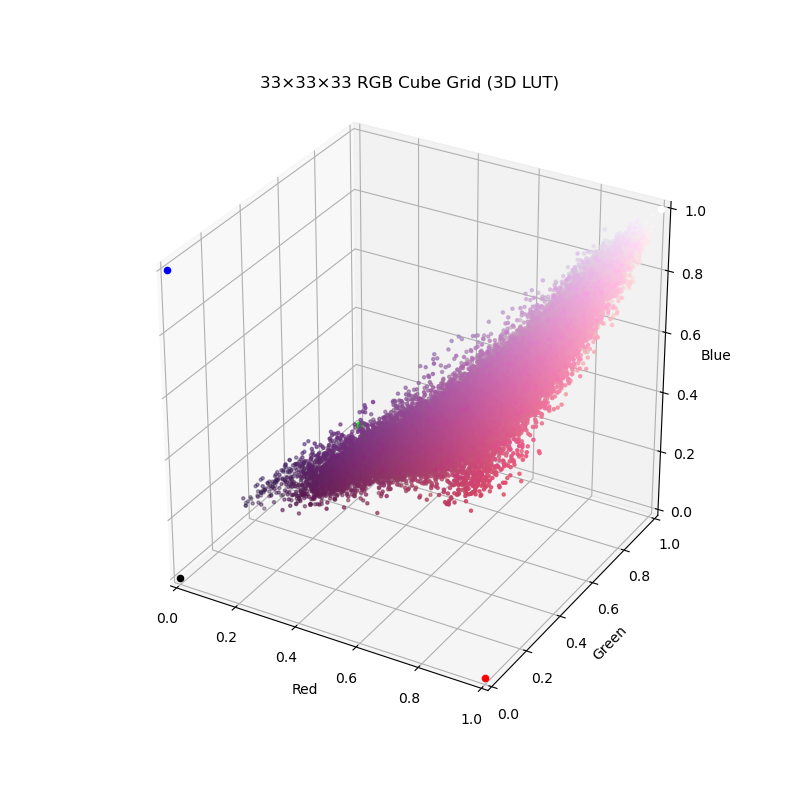

In [8]:
# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

def plot_3dcolor(img, ax, title, s=5):

    ax.scatter(
        img[:,0]/255.0,
        img[:,1]/255.0,
        img[:,2]/255.0,
        c=img/255,
        s=s,
        marker='o'
    )
    
    ax.scatter(1,0,0,color=[1,0,0], s=20, marker='o')
    ax.scatter(0,1,0,color=[0,1,0], s=20, marker='o')
    ax.scatter(0,0,1,color=[0,0,1], s=20, marker='o')
    ax.scatter(0,0,0,color=[0,0,0], s=20, marker='o')
    ax.scatter(1,1,1,color=[1,1,1], s=20, marker='o')
    
    # Axes labels
    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_zlim(0,1)
    
    ax.set_title(title)
    
    # Equal aspect ratio
    ax.set_box_aspect([1, 1, 1])
    
    # plt.show()

plot_3dcolor(img_0c, ax, '33×33×33 RGB Cube Grid (3D LUT)')

In [9]:
def plot_3dcolor_OD(img, color, ax, title, s=5):

    ax.scatter(
        img[:,0]/255.0,
        img[:,1]/255.0,
        img[:,2]/255.0,
        c=color/255,
        s=s,
        marker='o'
    )
    
    # ax.scatter(1,0,0,color=[1,0,0], s=20, marker='o')
    # ax.scatter(0,1,0,color=[0,1,0], s=20, marker='o')
    # ax.scatter(0,0,1,color=[0,0,1], s=20, marker='o')
    # ax.scatter(0,0,0,color=[0,0,0], s=20, marker='o')
    # ax.scatter(1,1,1,color=[1,1,1], s=20, marker='o')
    
    # Axes labels
    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    
    # ax.set_xlim(0,1)
    # ax.set_ylim(0,1)
    # ax.set_zlim(0,1)
    
    ax.set_title(title)
    
    # Equal aspect ratio
    ax.set_box_aspect([1, 1, 1])
    
    # plt.show()

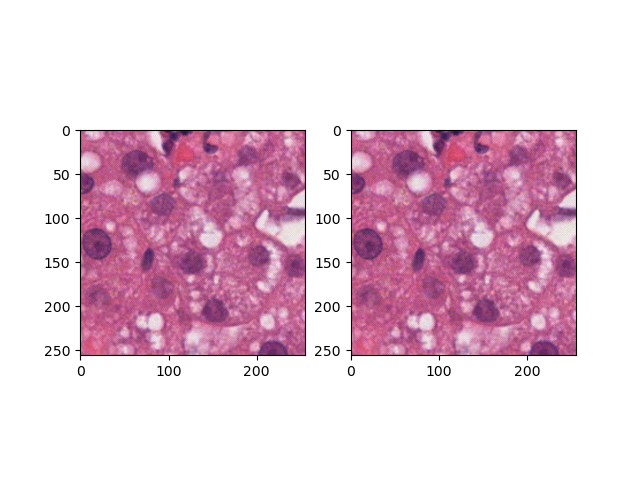

In [10]:
plt.figure()
bins = 33  # number of bins per channel
q = (img_0.astype(np.uint16) * bins) // 256
quantized = np.clip(
    np.round((q + 0.5) * 256 / bins),
    0, 255
).astype(np.uint8)
plt.subplot(121)
plt.imshow(img_0)
plt.subplot(122)
plt.imshow(quantized)

# plt.plot(np.arange(len(quantized)),quantized[:,0])


In [11]:
L = 33  # number of bins per channel
quan_c = quantized.reshape(-1,3)
unique_colors, color_count = np.unique(quan_c, return_counts =True, axis=0)
print(unique_colors.shape)
print(color_count.shape)

(1714, 3)
(1714,)


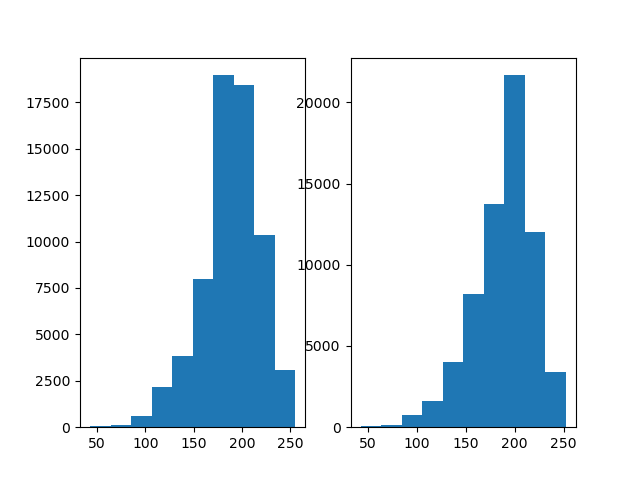

In [12]:
plt.figure()
plt.subplot(121)
plt.hist(img_0c[:,0])
plt.subplot(122)
plt.hist(quan_c[:,0])


plt.show()

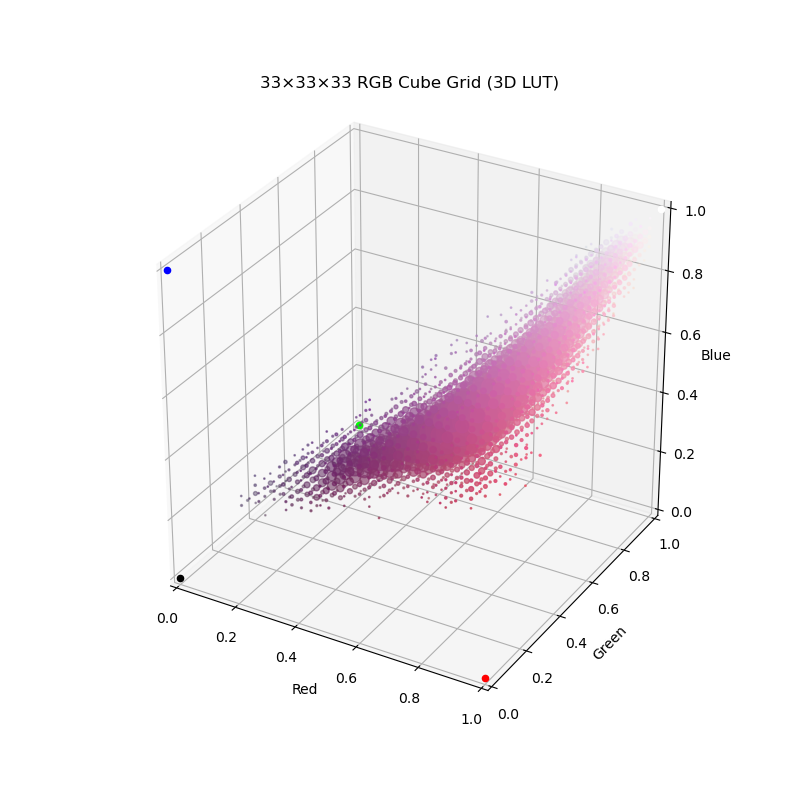

In [13]:
# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

plot_3dcolor(unique_colors, ax, '33×33×33 RGB Cube Grid (3D LUT)', s=color_count)

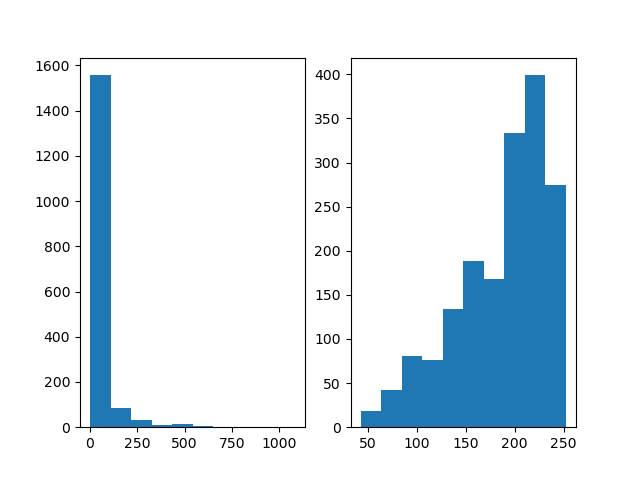

In [14]:
plt.figure()
plt.subplot(121)
plt.hist(color_count)
plt.subplot(122)
plt.hist(unique_colors[:,0])


plt.show()


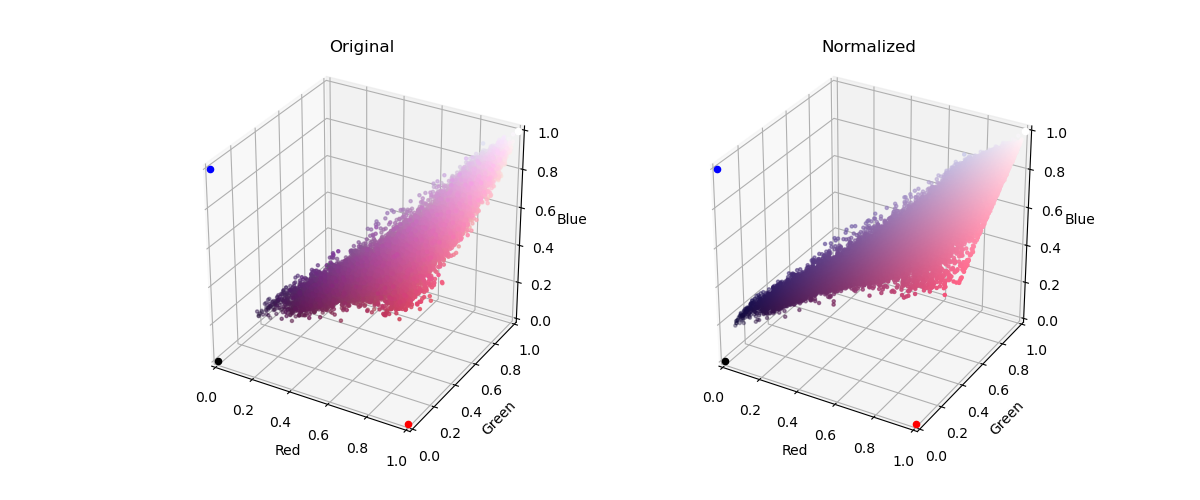

In [15]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')
#SECOND PLOT
norm_0c= norm_0.reshape(-1,3)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

plot_3dcolor(img_0c, ax, 'Original')
plot_3dcolor(norm_0c, ax2, 'Normalized')


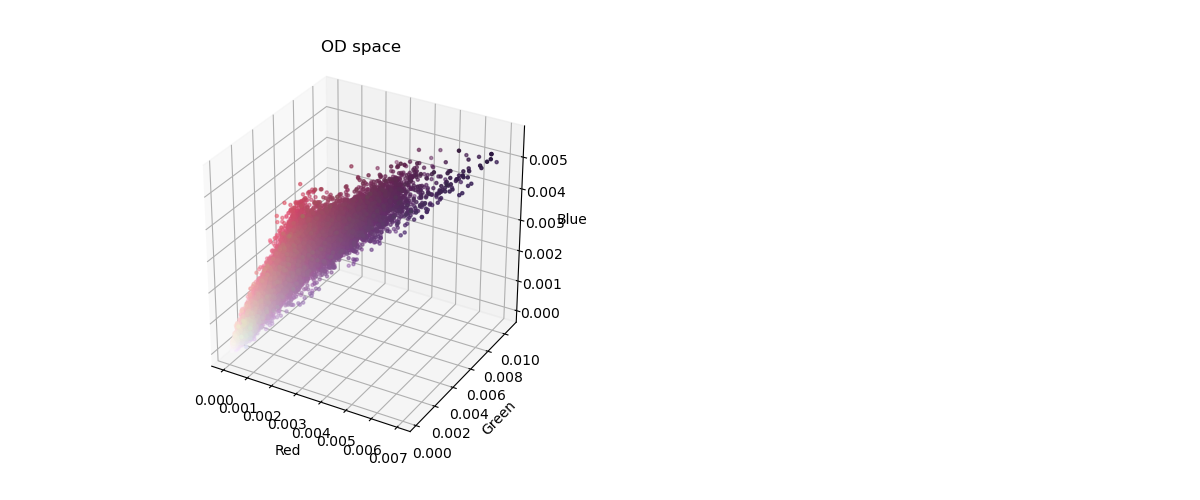

In [16]:
img_0_OD = -np.log(img_0 / 256).reshape(-1,3)

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
plot_3dcolor_OD(img_0_OD, img_0c, ax, 'OD space', s=5)


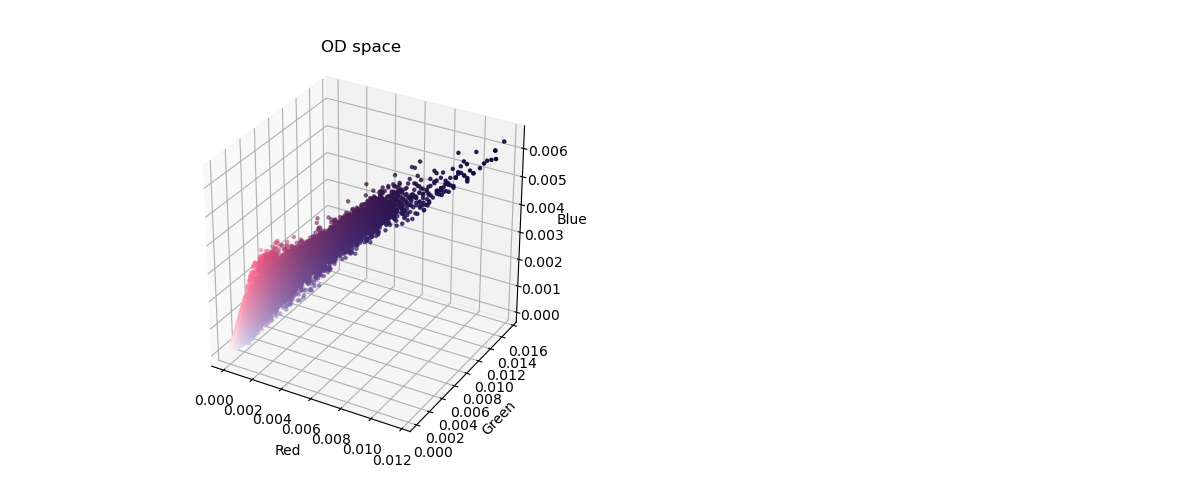

In [17]:
norm_OD = -np.log(norm_0 / 256).reshape(-1,3)

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
plot_3dcolor_OD(norm_OD, norm_0c, ax, 'OD space', s=5)


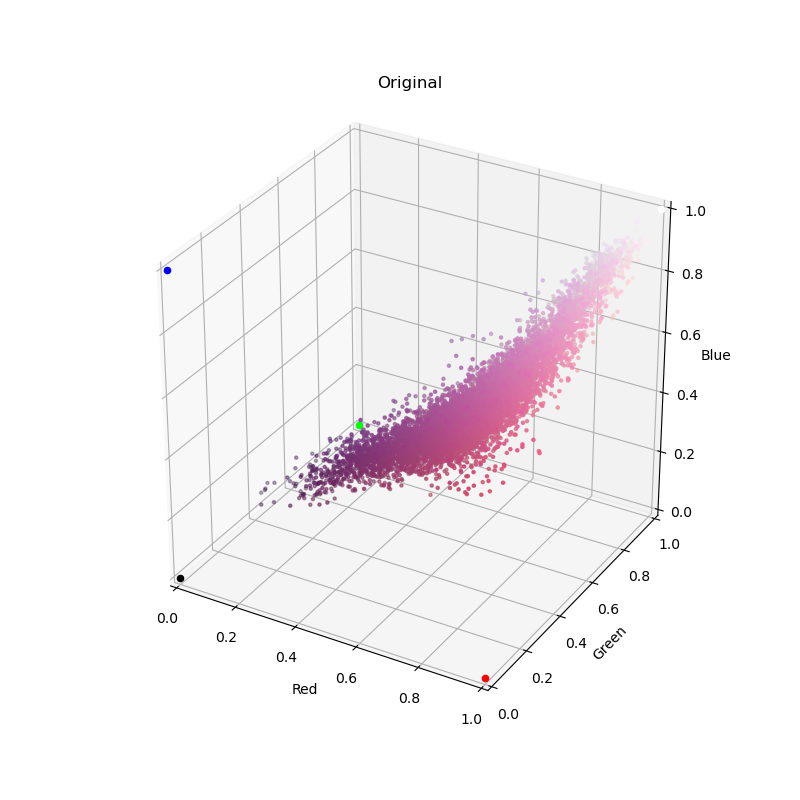

In [18]:
img_0c.shape
rng = np.random.default_rng()
sampled_i0c = rng.choice(img_0c, size=10000, replace=False,axis=0)
sampled_i0c.shape

# Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
plot_3dcolor(sampled_i0c, ax, 'Original')

# Experiment


In [19]:
A = img_0
B = norm_0

bins = 33
Aq = (A.astype(np.uint16) * bins) // 256

lut = np.zeros((bins,bins,bins,3), dtype=np.float64)
count = np.zeros((bins,bins,bins), dtype=np.int32)

for (r,g,b), out in zip(Aq.reshape(-1,3), B.reshape(-1,3)):
    lut[r,g,b] += out
    count[r,g,b] += 1

mask = count > 0
lut[mask] /= count[mask][...,None]


In [20]:
Bout = lut[
    Aq[...,0],
    Aq[...,1],
    Aq[...,2]
]



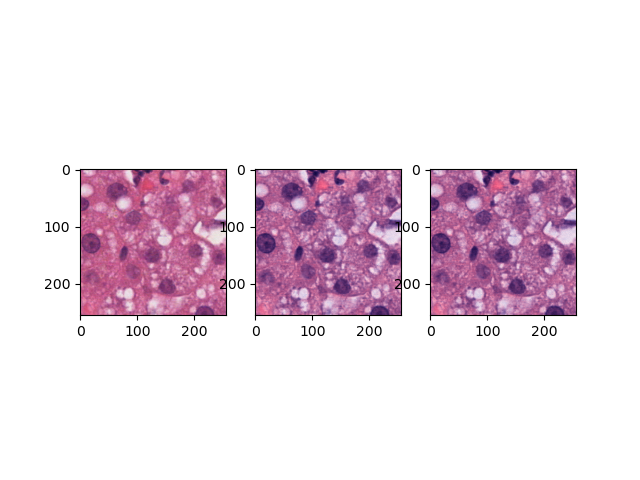

In [21]:
plt.figure()
plt.subplot(131)
plt.imshow(A)
plt.subplot(132)
plt.imshow(B)
plt.subplot(133)
plt.imshow(Bout.astype('uint8'))

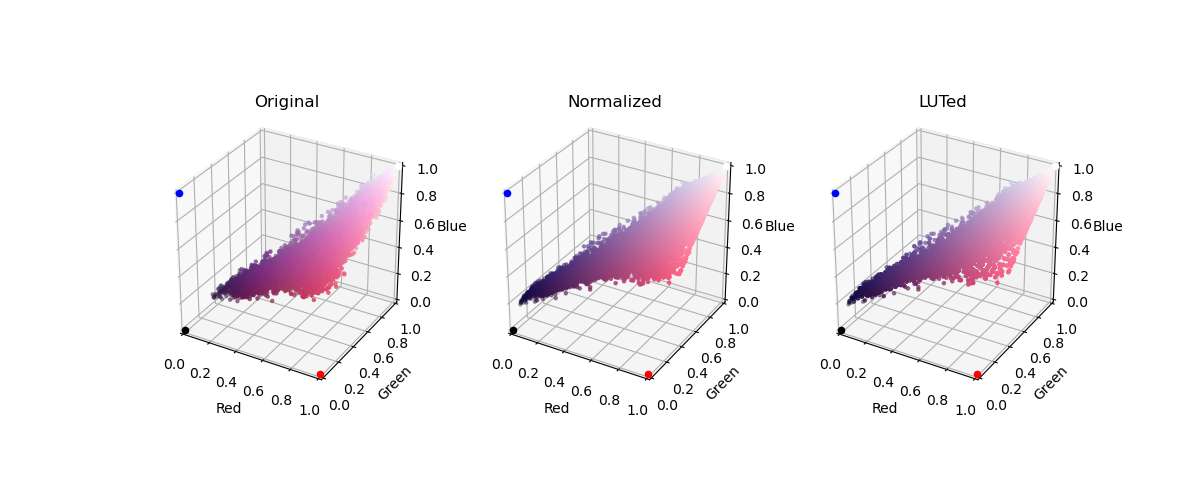

In [22]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 3, 1, projection='3d')
#SECOND PLOT
norm_0c= norm_0.reshape(-1,3)
ax2 = fig.add_subplot(1, 3, 2, projection='3d')

#THIRD PLOT
Boutc= Bout.reshape(-1,3)
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

plot_3dcolor(img_0c, ax, 'Original')
plot_3dcolor(norm_0c, ax2, 'Normalized')
plot_3dcolor(Boutc, ax3, 'LUTed')


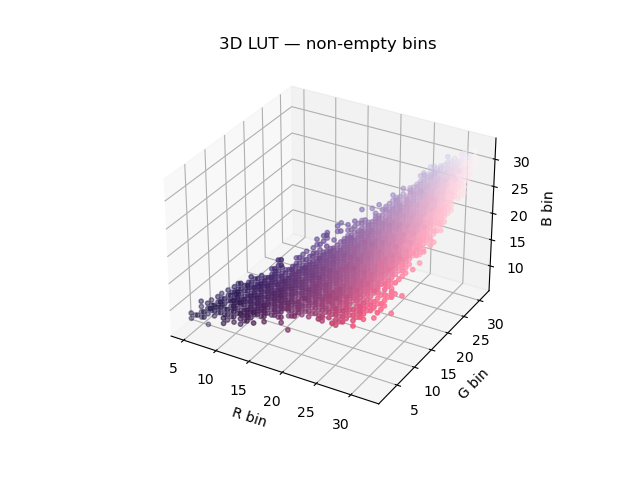

In [23]:
# Indices of non-empty bins
i, j, k = np.where(count > 0)

# Input-bin coordinates (optional: map to [0,255])
x = i
y = j
z = k

# Output colors (normalize to [0,1] for matplotlib)
colors = lut[i, j, k] / 255.0

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c=colors, s=10)

ax.set_xlabel("R bin")
ax.set_ylabel("G bin")
ax.set_zlabel("B bin")
ax.set_title("3D LUT — non-empty bins")

plt.show()


In [24]:
def vis_lut(lut, lut_dim):
    step = 1.0 / (lut_dim - 1)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    for b in range(lut_dim):

        for g in range(lut_dim):
            # vectorization for efficiency
            r = np.arange(lut_dim)
            ax.scatter(b * step * np.ones(lut_dim),
                       g * step * np.ones(lut_dim),
                       r * step,
                       c=lut[b, g, r],
                       marker='o',
                       alpha=1.0)
    ax.set_xlabel('B')
    ax.set_ylabel('G')
    ax.set_zlabel('R')
    plt.show()

In [25]:
lut/255

array([[[[0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],

        [[0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],

        [[0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         ...,
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]],

        ...,

        [[0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        ]

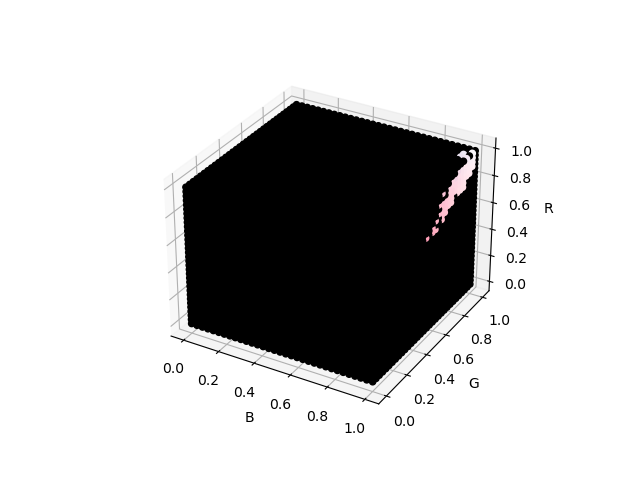

In [26]:
vis_lut(lut/255,bins)